<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 1.2853 acc 0.555 | val loss 0.9051 acc 0.663 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.7748 acc 0.707 | val loss 0.6113 acc 0.749 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.4846 acc 0.783 | val loss 0.4487 acc 0.827 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.3648 acc 0.844 | val loss 0.3689 acc 0.856 *


...

[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.00e-05 | train loss 0.0924 acc 0.949 | val loss 0.3501 acc 0.888


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.00e-06 | train loss 0.0859 acc 0.968 | val loss 0.4331 acc 0.893


[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.00e-06 | train loss 0.0562 acc 0.981 | val loss 0.3445 acc 0.910


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.00e-06 | train loss 0.0381 acc 0.980 | val loss 0.3660 acc 0.902


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.00e-06 | train loss 0.0258 acc 0.989 | val loss 0.3735 acc 0.915

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3048)


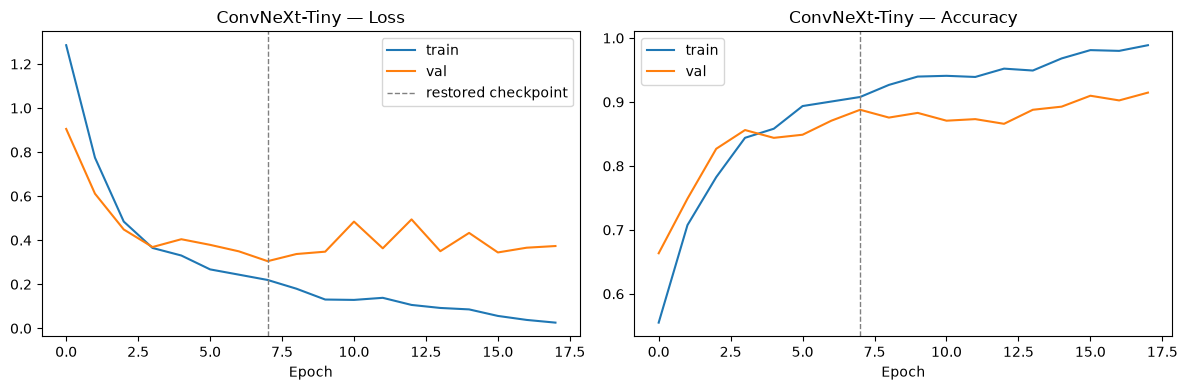

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.867


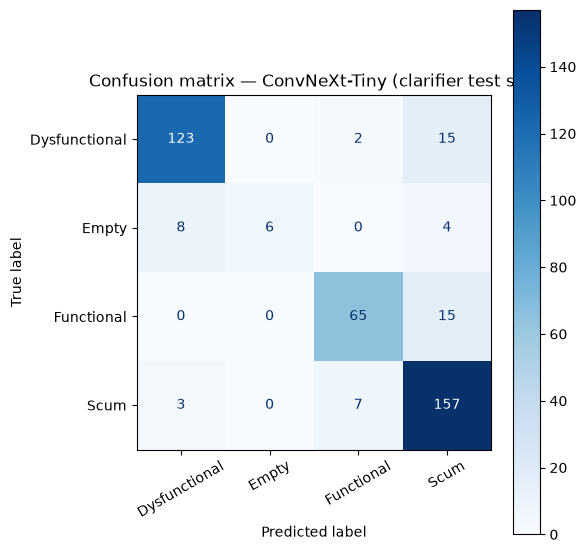

               precision    recall  f1-score   support

Dysfunctional      0.918     0.879     0.898       140
        Empty      1.000     0.333     0.500        18
   Functional      0.878     0.812     0.844        80
         Scum      0.822     0.940     0.877       167

     accuracy                          0.867       405
    macro avg      0.905     0.741     0.780       405
 weighted avg      0.874     0.867     0.861       405



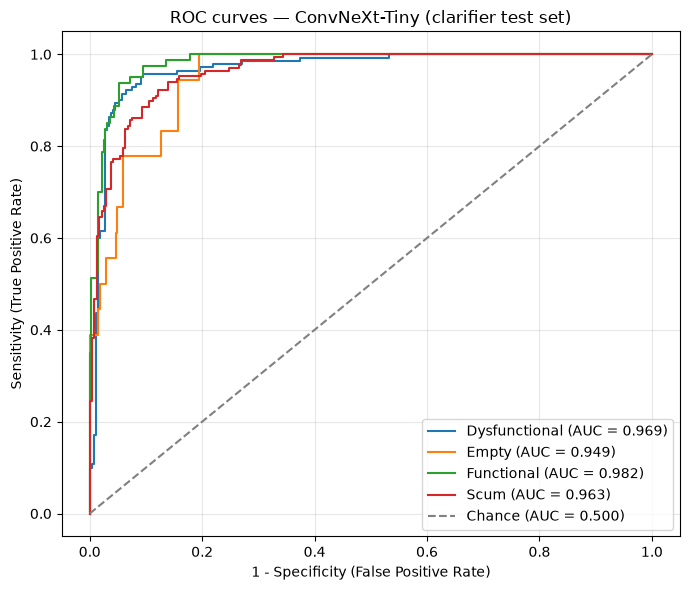

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Empty          : 0.949
  Functional     : 0.982
  Scum           : 0.963

Mean AUC (over 4/4 classes with test examples): 0.966


(np.float64(0.8666666666666667),
 {'Dysfunctional': 0.9685175202156334,
  'Empty': 0.9493252942865346,
  'Functional': 0.9817307692307693,
  'Scum': 0.9629899864137271})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
